In [30]:
!pip install -q transformers datasets peft accelerate evaluate scikit-learn matplotlib seaborn

In [31]:
import torch

In [32]:
import numpy as np

In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer ,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    PeftModel
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
MODEL_NAME   = "distilbert-base-uncased"
NUM_LABELS   = 4
MAX_LENGTH   = 128
BATCH_SIZE   = 16
NUM_EPOCHS   = 5
LEARNING_RATE = 2e-4
OUTPUT_DIR   = "./cybersec-lora-model"
LABEL2ID = {"benign": 0, "anomaly": 1, "threat": 2, "critical": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [34]:


benign_samples = [
    "User logged in successfully from recognized device.",
    "Scheduled backup completed without errors.",
    "DNS query resolved to known internal server.",
    "File accessed by authorized user during business hours.",
    "Routine vulnerability scan completed. No issues found.",
    "SSH connection established from whitelisted IP.",
    "Software update installed on endpoint successfully.",
    "Employee accessed HR portal from corporate network.",
    "Certificate renewal completed for internal service.",
    "Firewall rule updated by administrator.",
    "API health check returned 200 OK.",
    "Database connection pool maintained at optimal level.",
    "Email sent from verified corporate account.",
    "VPN tunnel established from known remote user.",
    "Log rotation completed successfully.",
    "Patch deployment finished with zero failures.",
    "Cloud storage sync completed for authorized bucket.",
    "Service account token refreshed on schedule.",
    "Network latency within expected thresholds.",
    "Antivirus definitions updated to latest version.",
    "User password changed through self-service portal.",
    "Audit log exported by compliance team.",
    "Container image pulled from internal registry.",
    "TLS handshake successful with trusted certificate.",
    "Disk usage at 62%, within normal range.",
    "CPU utilization spike during scheduled batch job.",
    "User account unlocked by help desk.",
    "NAC policy applied to new device on corporate Wi-Fi.",
    "Security awareness training completion recorded.",
    "Configuration drift remediated by automation script.",
    "Internal port scan detected from vulnerability scanner.",
    "LDAP bind successful for authenticated user.",
    "MFA token validated for privileged access.",
    "Report generated and emailed to CISO team.",
    "Kubernetes pod restarted due to memory limit.",
    "Load balancer health check passed.",
    "Proxy traffic filtered by content policy.",
    "Backup encryption key rotated per policy.",
    "User group membership updated by IT admin.",
    "S3 bucket lifecycle policy applied successfully.",
] * 5  # 200 samples

anomaly_samples = [
    "Login attempt from unusual geographic location.",
    "High volume of failed authentication attempts detected.",
    "User accessed sensitive file outside normal hours.",
    "Unexpected outbound connection to unknown IP.",
    "Service account used interactively — not expected.",
    "DNS query to newly registered domain.",
    "Large data transfer to external cloud storage.",
    "User logged in from two locations simultaneously.",
    "Admin account used from non-admin workstation.",
    "Process spawned unexpected child process.",
    "Unusual port opened on production server.",
    "Spike in API calls from single authenticated user.",
    "Config file modified outside change management window.",
    "Privileged command executed by standard user account.",
    "Email attachment opened from suspicious sender domain.",
    "Repeated access to same resource by same user in loop.",
    "New user agent string detected for existing account.",
    "Certificate fingerprint mismatch on internal service.",
    "RDP connection from unrecognized machine.",
    "Database query pattern deviation detected.",
    "PowerShell execution policy bypassed on endpoint.",
    "Unusual parent-child process relationship detected.",
    "Login from TOR exit node.",
    "High number of permission denial events.",
    "Scheduled task created by non-admin user.",
    "Service installed without change ticket.",
    "Access to decommissioned system attempted.",
    "Sudden increase in email forwarding rules.",
    "File compressed and sent externally.",
    "Cloud API called from unregistered application.",
    "SSH key added to authorized_keys without approval.",
    "Memory usage spike with no corresponding process.",
    "Registry key modified by unexpected process.",
    "Browser extension installed with high privilege.",
    "Unusual beacon pattern from endpoint to external IP.",
    "Account queried Active Directory bulk user info.",
    "VPN authentication from new country.",
    "Multiple failed MFA prompts for admin user.",
    "Executable run from temp directory.",
    "Network share enumeration by user account.",
] * 5  # 200 samples

threat_samples = [
    "Malware signature detected in downloaded file.",
    "Command and control communication detected.",
    "Known ransomware hash found on endpoint.",
    "Credential dumping tool LSASS dump initiated.",
    "Lateral movement detected via pass-the-hash.",
    "Phishing link clicked by user — credential harvest page.",
    "Suspicious PowerShell encoded command executed.",
    "Rootkit behavior detected in kernel space.",
    "Keylogger detected on workstation.",
    "Unauthorized access to PII database confirmed.",
    "Privilege escalation attempt via CVE-2023-XXXX.",
    "Reverse shell connection opened on port 4444.",
    "SQL injection payload detected in web logs.",
    "Brute force attack on admin panel confirmed.",
    "Exfiltration of 500MB to foreign IP detected.",
    "Cryptominer binary found running on cloud instance.",
    "Spear phishing email opened by executive.",
    "Zero-day exploit pattern matched in IDS rule.",
    "Unauthorized SSH tunnel established to external host.",
    "Token stolen and replayed from different IP.",
    "Malicious macro executed in Office document.",
    "DLL injection detected in running process.",
    "Threat actor IP matched in threat intelligence feed.",
    "Ransomware file extension pattern detected.",
    "Data encrypted in bulk without user action.",
    "Multiple shadow copies deleted — ransomware indicator.",
    "Firewall rule disabled from compromised account.",
    "Known APT tool signature found in memory.",
    "NTDS.dit copied to removable storage.",
    "Golden ticket attack pattern detected in Kerberos logs.",
    "Persistence mechanism added via startup folder.",
    "C2 beacon detected with jitter pattern.",
    "Admin credentials found in cleartext in log file.",
    "Domain admin account used from endpoint in DMZ.",
    "Log tampering detected — audit logs cleared.",
    "Malicious package installed via npm supply chain.",
    "Exfiltration via DNS tunneling detected.",
    "Cloud credentials hardcoded in public repository.",
    "SSRF attack successful on internal metadata endpoint.",
    "Adversary-in-the-middle attack detected on Wi-Fi.",
] * 5  # 200 samples

critical_samples = [
    "Active ransomware encryption in progress across 40 hosts.",
    "Full domain compromise confirmed — all admin accounts breached.",
    "Data breach: 50,000 customer records exfiltrated.",
    "Critical infrastructure SCADA system under active attack.",
    "CISO notified: confirmed APT intrusion in progress.",
    "Production database dropped by attacker.",
    "Attacker has domain admin, moving laterally at scale.",
    "All backup systems encrypted — recovery path blocked.",
    "Ransomware note found on file server — operations halted.",
    "Active exfiltration of intellectual property detected.",
    "Nation-state actor confirmed in network — IOCs matched.",
    "Zero-day exploited in edge device — full shell access.",
    "Payment processing system compromised — card data at risk.",
    "CEO email account hijacked — wire fraud attempt in progress.",
    "Supply chain compromise confirmed in third-party software.",
    "Cloud environment fully compromised — all instances infected.",
    "Network segmentation bypassed — attacker in OT network.",
    "Destructive wiper malware deployed across enterprise.",
    "Active DDoS attack taking down public-facing services.",
    "Attacker established persistent backdoor in firmware.",
    "Legal and compliance team notified of confirmed breach.",
    "Incident response team activated — code red declared.",
    "Attacker pivoted to air-gapped system via removable media.",
    "Medical device network compromised — patient data at risk.",
    "Ransomware spreading via worm capability across subnets.",
    "All encryption keys wiped by attacker — data unrecoverable.",
    "Financial fraud: $2M unauthorized transfer initiated.",
    "Email system down — attacker deleted all mailboxes.",
    "Attacker enabled MFA bypass for all admin accounts.",
    "Active intrusion confirmed in military contractor network.",
    "Credentials of all service accounts leaked on dark web.",
    "Multi-cloud environment breached — cross-tenant access.",
    "Entire CI/CD pipeline compromised — malicious builds deployed.",
    "Emergency shutdown triggered at power utility — cyberattack.",
    "Hospital systems offline — ransomware affecting patient care.",
    "All domain controllers encrypted — AD unavailable.",
    "Attacker exfiltrating data live — 1GB/min transfer rate.",
    "Root CA certificate compromised — all certs untrusted.",
    "Active exploitation of 3 critical CVEs simultaneously.",
    "Threat actor issued public ransom demand — breach confirmed.",
] * 5
texts = benign_samples + anomaly_samples + threat_samples + critical_samples
labels = [0]*200 + [1]*200 + [2]*200 + [3]*200
df= pd.DataFrame({"text": texts, "label": labels})
df= df.sample ( frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset size: {len(df)}")
print(df["label"].value_counts().rename(index=ID2LABEL))

Dataset size: 800
label
critical    200
benign      200
threat      200
anomaly     200
Name: count, dtype: int64


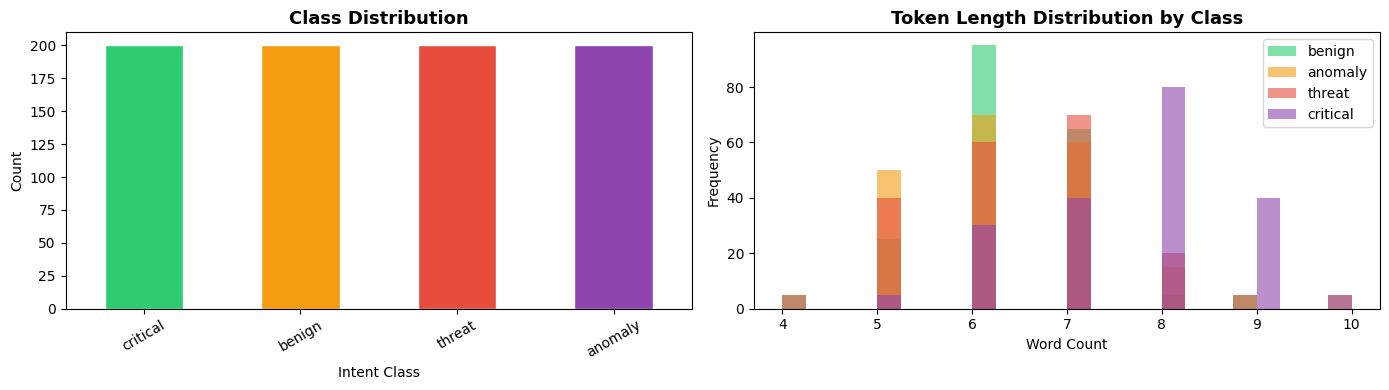


Text length stats:
          count  mean  std  min  25%  50%  75%   max
label                                               
benign    200.0   6.3  0.9  4.0  6.0  6.0  7.0   9.0
anomaly   200.0   6.3  1.1  5.0  5.8  6.0  7.0  10.0
threat    200.0   6.4  1.1  4.0  6.0  6.0  7.0   9.0
critical  200.0   7.7  1.1  5.0  7.0  8.0  8.0  10.0


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"]
df["label"].value_counts().rename(index=ID2LABEL).plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="white"
)
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Intent Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

df["text_len"] = df["text"].apply(lambda x: len(x.split()))
for i, (lbl, color) in enumerate(zip(["benign","anomaly","threat","critical"], colors)):
    subset = df[df["label"] == i]["text_len"]
    axes[1].hist(subset, bins=20, alpha=0.6, label=lbl, color=color)
axes[1].set_title("Token Length Distribution by Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nText length stats:")
print(df.groupby("label")["text_len"].describe().rename(index=ID2LABEL).round(1))

In [36]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["text", "label"]])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

print("Tokenization complete.")
print(f"Features: {train_ds.features}")

Train: 640 | Val: 80 | Test: 80


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Tokenization complete.
Features: {'text': Value('string'), 'label': Value('int64'), '__index_level_0__': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [37]:

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


In [38]:
pip install -U transformers datasets evaluate accelerate

In [39]:
import numpy as np
import torch

from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_steps=100,

    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_steps=10,

    report_to="none",

    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(" Starting fine-tuning...")
train_result = trainer.train()

print("Training complete!")
print(f"Training time: {train_result.metrics['train_runtime']:.1f}s")
print(f"Samples/sec:   {train_result.metrics['train_samples_per_second']:.1f}")

 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.359827,1.338550,0.437500,0.403961
2,1.048003,1.001239,0.587500,0.541268
3,0.544606,0.437665,0.862500,0.862714
4,0.310571,0.205044,0.975000,0.975275
5,0.191201,0.149387,0.987500,0.987492


Training complete!
Training time: 11.3s
Samples/sec:   283.5


In [40]:

predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("=" * 55)
print("         TEST SET EVALUATION RESULTS")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(true_labels, preds):.4f}")
print(f"  F1 Score : {f1_score(true_labels, preds, average='weighted'):.4f}")
print("=" * 55)
print("\nPer-Class Report:")
print(classification_report(
    true_labels, preds,
    target_names=[ID2LABEL[i] for i in range(NUM_LABELS)]
))

         TEST SET EVALUATION RESULTS
  Accuracy : 0.9500
  F1 Score : 0.9499

Per-Class Report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00        20
     anomaly       0.86      0.95      0.90        20
      threat       0.94      0.85      0.89        20
    critical       1.00      1.00      1.00        20

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



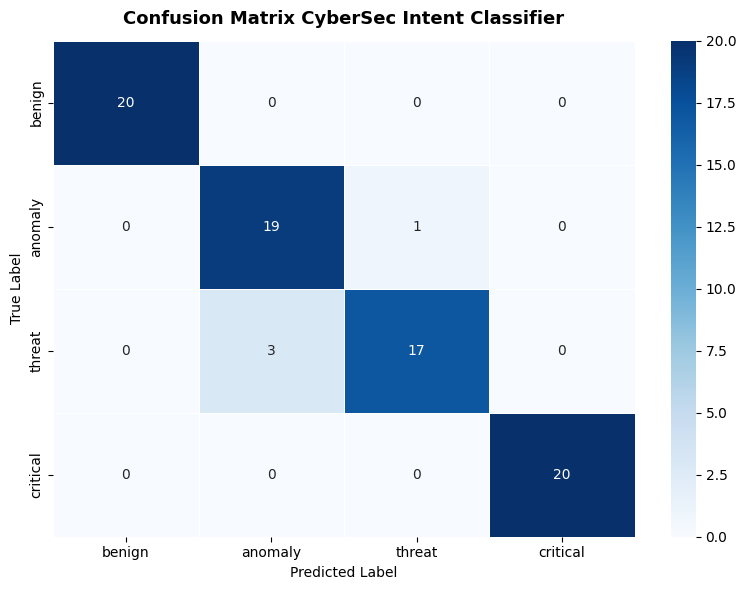

In [42]:
cm = confusion_matrix(true_labels, preds)
class_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    linewidths=0.5
)
plt.title("Confusion Matrix CyberSec Intent Classifier", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

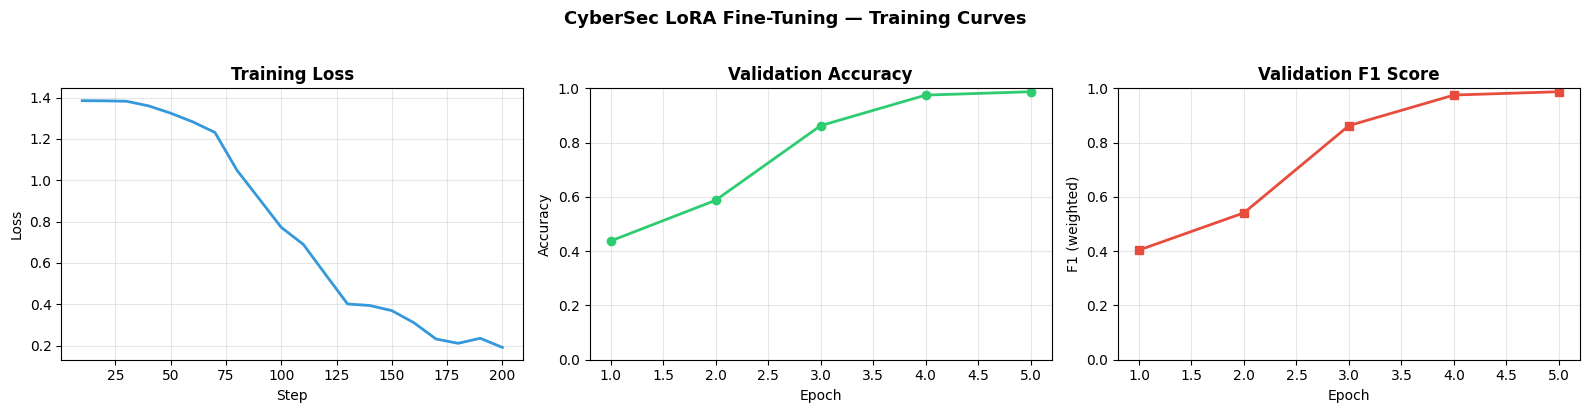

In [43]:
log_history = trainer.state.log_history

train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot([x["step"] for x in train_logs], [x["loss"] for x in train_logs],
             color="#3498db", linewidth=2)
axes[0].set_title("Training Loss", fontweight="bold")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[1].plot([x["epoch"] for x in eval_logs], [x["eval_accuracy"] for x in eval_logs],
             color="#2ecc71", linewidth=2, marker="o")
axes[1].set_title("Validation Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

axes[2].plot([x["epoch"] for x in eval_logs], [x["eval_f1"] for x in eval_logs],
             color="#e74c3c", linewidth=2, marker="s")
axes[2].set_title("Validation F1 Score", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 (weighted)")
axes[2].set_ylim([0, 1])
axes[2].grid(alpha=0.3)

plt.suptitle("CyberSec LoRA Fine-Tuning — Training Curves", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:

merged_model = model.merge_and_unload()

model.save_pretrained(OUTPUT_DIR + "/lora_adapter")
tokenizer.save_pretrained(OUTPUT_DIR + "/lora_adapter")
merged_model.save_pretrained(OUTPUT_DIR + "/merged_model")
tokenizer.save_pretrained(OUTPUT_DIR + "/merged_model")

print(f"LoRA adapter saved to: {OUTPUT_DIR}/lora_adapter")
print(f" Merged model saved to: {OUTPUT_DIR}/merged_model")

import os
def dir_size_mb(path):
    total = 0
    for dirpath, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1e6

adapter_size = dir_size_mb(OUTPUT_DIR + "/lora_adapter")
merged_size  = dir_size_mb(OUTPUT_DIR + "/merged_model")

print(f"\nLoRA adapter size : {adapter_size:.1f} MB")
print(f" Merged model size : {merged_size:.1f} MB")
print(f" Storage savings   : {(1 - adapter_size/merged_size)*100:.1f}%")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA adapter saved to: ./cybersec-lora-model/lora_adapter
 Merged model saved to: ./cybersec-lora-model/merged_model

LoRA adapter size : 0.7 MB
 Merged model size : 268.6 MB
 Storage savings   : 99.7%


In [46]:
model.save_pretrained(OUTPUT_DIR + "/lora_adapter")
tokenizer.save_pretrained(OUTPUT_DIR + "/lora_adapter")
merged_model.save_pretrained(OUTPUT_DIR + "/merged_model")
tokenizer.save_pretrained(OUTPUT_DIR + "/merged_model")
print(f"LoRA adapter saved to: {OUTPUT_DIR}/lora_adapter")
print(f" Merged model saved to: {OUTPUT_DIR}/merged_model")
import os
def dir_size_mb(path):
    total = 0
    for dirpath, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1e6

adapter_size = dir_size_mb(OUTPUT_DIR + "/lora_adapter")
merged_size  = dir_size_mb(OUTPUT_DIR + "/merged_model")

print(f"\nLoRA adapter size : {adapter_size:.1f} MB")
print(f" Merged model size : {merged_size:.1f} MB")
print(f" Storage savings   : {(1 - adapter_size/merged_size)*100:.1f}%")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA adapter saved to: ./cybersec-lora-model/lora_adapter
 Merged model saved to: ./cybersec-lora-model/merged_model

LoRA adapter size : 0.7 MB
 Merged model size : 268.6 MB
 Storage savings   : 99.7%
